The metric we're going for here is 

>**$n*β^r/β$** 

where $β^r$ is the number of barys + oxys responsion groups, $β$ is the number of all barys + oxys accents in all strophes and $n$ is the number of strophes. 

In [2]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

print(ROOT)

/home/urdatorn/git/gh/aristophanis-cantica


# Corpus

In [3]:
from aristophanis_cantica.stats_barys import barys_oxys_metric_corpus

corpus_dict = barys_oxys_metric_corpus(ROOT / 'data/compiled', exclude_substr='baseline')

for key, value in corpus_dict.items():
    print(f'\t{key}: {value}')

	barys_metric: 0.43811807012286486
	oxys_metric: 0.1783876500857633
	barys_oxys_metric: 0.3708638685320897


# Play regression

In [4]:
from aristophanis_cantica.stats_barys import barys_oxys_metric_play
from aristophanis_cantica.utils.utils import abbreviations

play_dict_barys = {}
for play in abbreviations: 
    play_dict_barys[play] = barys_oxys_metric_play(play)
    print(f'\t{play}:')
    for key, value in play_dict_barys[play].items():
        print(f'\t\t{key}: {value}')

print(play_dict_barys)

abbreviations_no_pl = [abbrev for abbrev in abbreviations if abbrev != 'pl']

play_dict_barys_no_pl = {}
for play in abbreviations_no_pl: 
    play_dict_barys_no_pl[play] = barys_oxys_metric_play(play)
    print(f'\t{play}:')
    for key, value in play_dict_barys_no_pl[play].items():
            print(f'\t\t{key}: {value}')


	ach:
		barys_metric: 0.43340857787810383
		oxys_metric: 0.18556701030927836
		barys_oxys_metric: 0.3579277864992151
	eq:
		barys_metric: 0.45965770171149145
		oxys_metric: 0.1320754716981132
		barys_oxys_metric: 0.39223300970873787
	nu:
		barys_metric: 0.5118483412322274
		oxys_metric: 0.41975308641975306
		barys_oxys_metric: 0.4863013698630137
	v:
		barys_metric: 0.4558139534883721
		oxys_metric: 0.1652892561983471
		barys_oxys_metric: 0.39201451905626133
	pax:
		barys_metric: 0.46397694524495675
		oxys_metric: 0.05172413793103448
		barys_oxys_metric: 0.36069114470842334
	av:
		barys_metric: 0.4578313253012048
		oxys_metric: 0.25
		barys_oxys_metric: 0.3902439024390244
	lys:
		barys_metric: 0.33587786259541985
		oxys_metric: 0.13253012048192772
		barys_oxys_metric: 0.27549194991055453
	th:
		barys_metric: 0.5272727272727272
		oxys_metric: 0.1875
		barys_oxys_metric: 0.4507042253521127
	ra:
		barys_metric: 0.3647342995169082
		oxys_metric: 0.12121212121212122
		barys_oxys_metric: 0.30

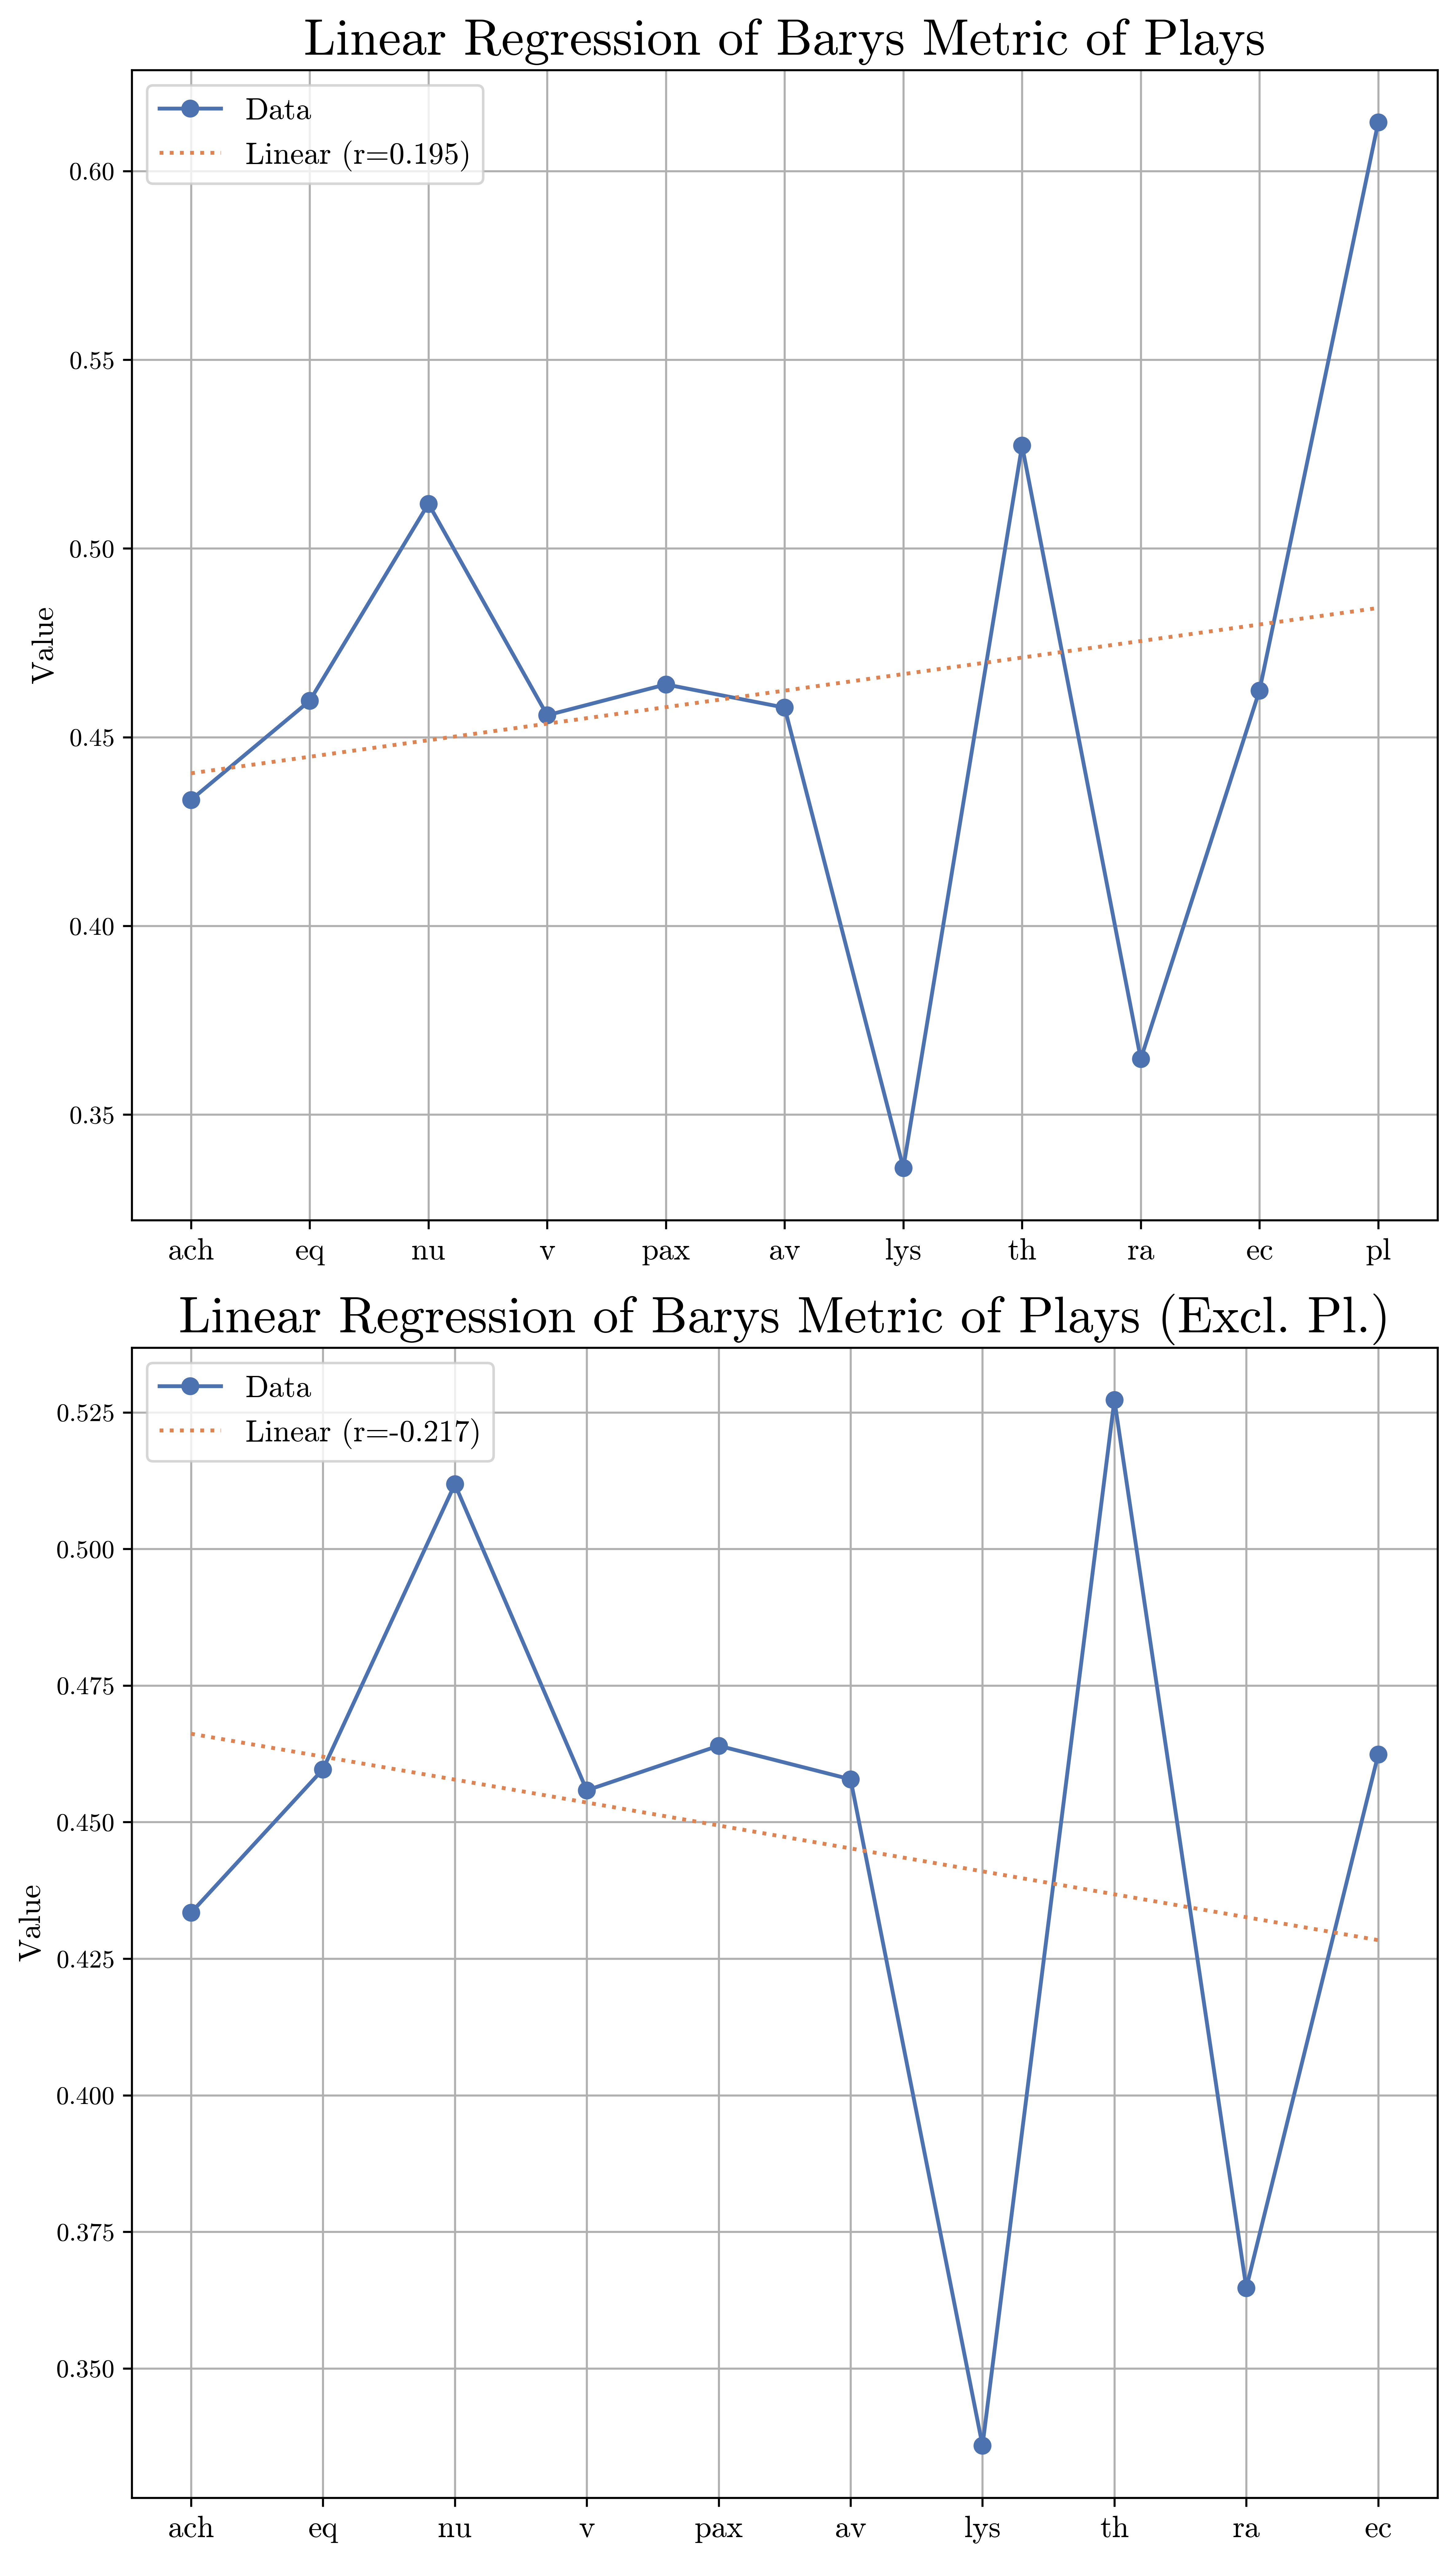

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from aristophanis_cantica.plot import apply_plotting_poetry_palette

apply_plotting_poetry_palette()
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


def plot_barys_regression(ax, data, title):
    keys = list(data.keys())
    x = np.arange(len(keys))
    y = np.array([data[k]['barys_metric'] for k in keys])

    # Connected data points
    ax.plot(x, y, marker='o', color=default_colors[0], label='Data', linewidth=1.5)

    # Linear regression
    X = x.reshape(-1, 1)
    linreg = LinearRegression().fit(X, y)
    y_pred = linreg.predict(X)

    # Pearson correlation coefficient
    r, p_value = pearsonr(x, y)
    ax.plot(x, y_pred, linestyle=':', color=default_colors[1], label=f'Linear (r={r:.3f})')

    # Aesthetics
    ax.set_title(title, fontsize=20)
    ax.set_xticks(x)
    ax.set_xticklabels(keys, fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(True)


# Single figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 14), sharex=False)

plot_barys_regression(axes[0], play_dict_barys, 'Linear Regression of Barys Metric of Plays')
plot_barys_regression(axes[1], play_dict_barys_no_pl, 'Linear Regression of Barys Metric of Plays (Excl. Pl.)')

plt.tight_layout()
plt.savefig(ROOT / 'media/play_regression/linreg_barys_combined.png', bbox_inches='tight', pad_inches=0.2)
plt.show()

# Detailed

{'ach01': {'barys_metric': 0.44776119402985076, 'oxys_metric': 0.15384615384615385, 'barys_oxys_metric': 0.3655913978494624}, 'ach02': {'barys_metric': 0.43137254901960786, 'oxys_metric': 0.37037037037037035, 'barys_oxys_metric': 0.41025641025641024}, 'ach03': {'barys_metric': 0.6428571428571429, 'oxys_metric': 0.15384615384615385, 'barys_oxys_metric': 0.4878048780487805}, 'ach04': {'barys_metric': 0.5882352941176471, 'oxys_metric': 0.24, 'barys_oxys_metric': 0.4406779661016949}, 'ach05': {'barys_metric': 0.10256410256410256, 'oxys_metric': 0.0, 'barys_oxys_metric': 0.08888888888888889}, 'ach06': {'barys_metric': 0.5263157894736842, 'oxys_metric': 0.2222222222222222, 'barys_oxys_metric': 0.48484848484848486}, 'ach07': {'barys_metric': 0.42857142857142855, 'oxys_metric': 0.17391304347826086, 'barys_oxys_metric': 0.302158273381295}, 'ach08': {'barys_metric': 0.43478260869565216, 'oxys_metric': 0.0, 'barys_oxys_metric': 0.4}, 'ach09': {'barys_metric': 0.35294117647058826, 'oxys_metric': 0

/tmp/ipykernel_988217/3243419843.py:63: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) cmr10.
  plt.tight_layout()
/home/urdatorn/.pyenv/versions/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


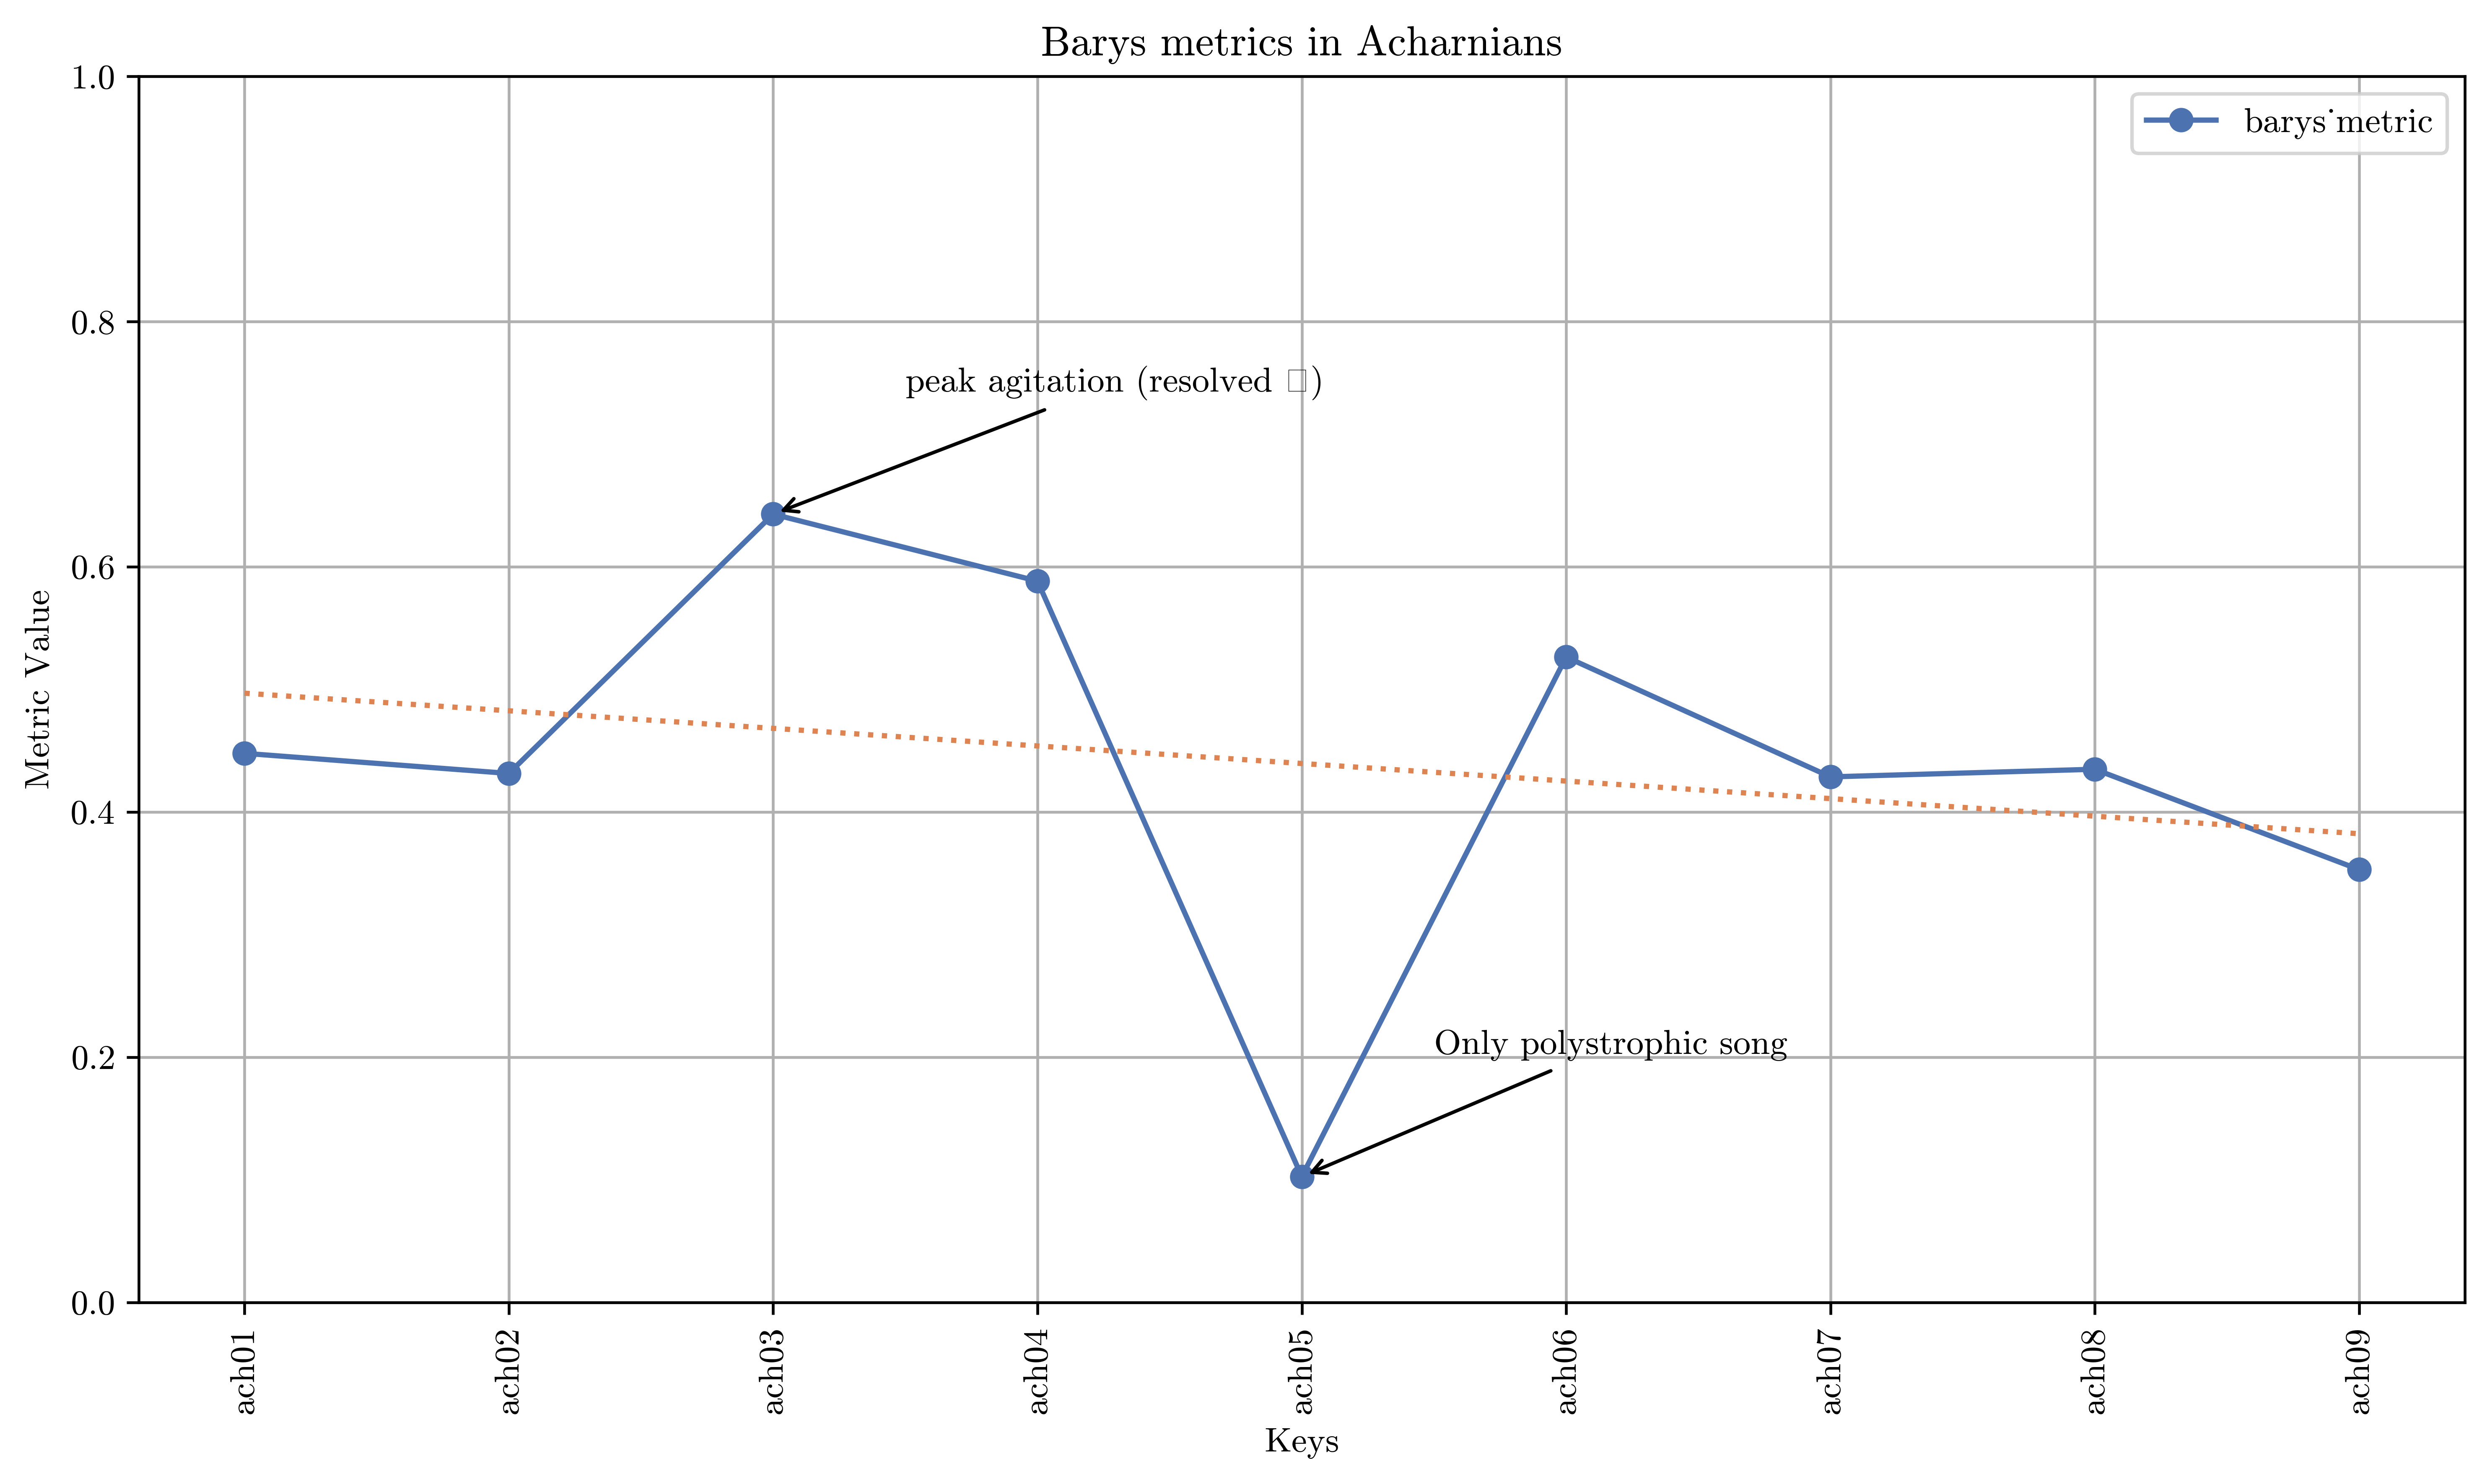

In [6]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

from aristophanis_cantica.plot import apply_plotting_poetry_palette
from aristophanis_cantica.stats_barys import barys_oxys_metric_canticum
from aristophanis_cantica.utils.utils import get_canticum_ids

apply_plotting_poetry_palette()
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

abbreviations = ["ach"]
canticum_ids = get_canticum_ids(abbreviations)

canticum_dict = {}
for canticum in canticum_ids:
    canticum_dict[canticum] = barys_oxys_metric_canticum(canticum)

print(canticum_dict)

data = canticum_dict

x_labels = list(data.keys())
x_numeric = np.arange(len(x_labels))

barys = [data[k]['barys_metric'] for k in x_labels]

plt.figure(figsize=(10, 6))
plt.plot(x_numeric, barys, marker='o', color=default_colors[0], label='barys_metric')

plt.annotate(
    "peak agitation (resolved δ)",
    xy=(x_numeric[2], barys[2]),
    xytext=(x_numeric[2] + 0.5, barys[2] + 0.1),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
    ha='left'
)

plt.annotate(
    "Only polystrophic song",
    xy=(x_numeric[4], barys[4]),
    xytext=(x_numeric[4] + 0.5, barys[4] + 0.1),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
    ha='left'
)

def plot_regression(x, y):
    model = LinearRegression().fit(x.reshape(-1, 1), y)
    y_pred = model.predict(x.reshape(-1, 1))
    plt.plot(x, y_pred, color=default_colors[1], linestyle=':')

plot_regression(x_numeric, np.array(barys))

plt.xticks(ticks=x_numeric, labels=x_labels, rotation=90)
plt.ylim(0, 1)
plt.xlabel("Keys")
plt.ylabel("Metric Value")
plt.title("Barys metrics in Acharnians")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
from lxml import etree

from aristophanis_cantica.stats_barys import barys_accentually_responding_syllables_of_strophes_polystrophic, count_all_barys_oxys_canticum

from aristophanis_cantica.utils.utils import abbreviations, get_canticum_ids, polystrophic_cantica

def barys_detailed_print(infix):

    input_file = ROOT / f"data/compiled/responsion_{infix}_compiled.xml"
    tree = etree.parse(input_file)

    canticum_ids = get_canticum_ids([infix])

    for responsion in canticum_ids:
        print(f"\nCanticum: {responsion}")
            
        all_barys_oxys_canticum_dict = count_all_barys_oxys_canticum(tree, responsion)
        print(all_barys_oxys_canticum_dict)
        sum_barys = all_barys_oxys_canticum_dict['barys']
        sum_oxys = all_barys_oxys_canticum_dict['oxys']
        sum_barys_oxys = sum_barys + sum_oxys

        strophes = tree.xpath(f'//strophe[@responsion="{responsion}"] | //antistrophe[@responsion="{responsion}"]') # bug fix (was only strophe)
        n = len(strophes)

        barys_oxys_results = barys_accentually_responding_syllables_of_strophes_polystrophic(*strophes)

        if not barys_oxys_results:
            print("No valid barys/oxys matches found.\n")
            continue  # Skip to next responsion if no results

        barys_list, oxys_list = barys_oxys_results

        print(f"Barys matches: {len(barys_list)}")
        print(f"Oxys matches:  {len(oxys_list)}\n")

        barys_metric = (n * len(barys_list)) / sum_barys if sum_barys > 0 else 0
        oxys_metric = (n * len(oxys_list)) / sum_oxys if sum_oxys > 0 else 0
        barys_oxys_metric = (n * (len(barys_list) + len(oxys_list))) / sum_barys_oxys if sum_barys_oxys > 0 else 0

        print(f"Barys metric: {barys_metric:.3f}")
        print(f"Oxys metric:  {oxys_metric:.3f}")
        print(f"Barys + Oxys metric: {barys_oxys_metric:.3f}\n")

        if responsion in polystrophic_cantica:
            if barys_list:
                print("--- BARYS MATCHES ---")
                for match_idx, match_set in enumerate(barys_list, start=1):
                    print(f"  Match #{match_idx}:")
                    for (line_id, unit_ord), text in match_set.items():
                        print(f"    (line {line_id}, ord={unit_ord}) => \"{text}\"")
                    print()

            if oxys_list:
                print("--- OXYS MATCHES ---")
                for match_idx, match_set in enumerate(oxys_list, start=1):
                    print(f"  Match #{match_idx}:")
                    for (line_id, unit_ord), text in match_set.items():
                        print(f"    (line {line_id}, ord={unit_ord}) => \"{text}\"")
                    print()
            
        else: 
            if barys_list:
                print("--- BARYS MATCHES ---")
                for i, pair_dict in enumerate(barys_list, start=1):
                    print(f"  Pair #{i}:")
                    for (line_id, unit_ord), text in pair_dict.items():
                        print(f"    (line {line_id}, ord={unit_ord}) => \"{text}\"")
                    print()

            if oxys_list:
                print("--- OXYS MATCHES ---")
                for i, pair_dict in enumerate(oxys_list, start=1):
                    print(f"  Pair #{i}:")
                    for (line_id, unit_ord), text in pair_dict.items():
                        print(f"    (line {line_id}, ord={unit_ord}) => \"{text}\"")
                    print()

for infix in abbreviations:
    barys_detailed_print(infix)


Canticum: ach01
{'barys': 67, 'oxys': 26}
Barys matches: 15
Oxys matches:  2

Barys metric: 0.448
Oxys metric:  0.154
Barys + Oxys metric: 0.366

--- BARYS MATCHES ---
  Pair #1:
    (line 204, ord=1) => "Τῇ"
    (line 219, ord=1) => "Νῦν"

  Pair #2:
    (line 205, ord=8) => "πάντων"
    (line 220, ord=8) => "τείδῃ"

  Pair #3:
    (line 205, ord=11) => "πόλει"
    (line 220, ord=11) => "κέλος"

  Pair #4:
    (line 206, ord=7) => "τοῦ"
    (line 221, ord=7) => "τέος"

  Pair #5:
    (line 207, ord=3) => "οἶ"
    (line 222, ord=3) => "δέπερ"

  Pair #6:
    (line 207, ord=5) => "δ' ὅποι"
    (line 222, ord=5) => "γέρον"

  Pair #7:
    (line 207, ord=15) => "φέρων"
    (line 222, ord=15) => "νέας"

  Pair #8:
    (line 208-209, ord=3) => "πέφευγ"
    (line 223-224, ord=3) => "ς, ὦ Ζ"

  Pair #9:
    (line 210-211, ord=4) => "ς. Οἴμοι"
    (line 225, ord=4) => "τοῖ"

  Pair #10:
    (line 210-211, ord=7) => "τῶν"
    (line 225, ord=7) => "θροῖ"

  Pair #11:
    (line 211-212, ord=4) =